## Punktoperationen Basics



##### Laden der Module

In [1]:
import numpy as np
import scipy
import cv2
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

##### Hilfsfunktionen laden

In [2]:
from modules.plotting import displayImageAndAllHist 

##### Einlesen des Bildes

Einlesen des Bildes und Anzeige der Bildinformationen

In [3]:
# Bilddateien einladen
image = cv2.imread(r'images/airplane.tif', cv2.IMREAD_GRAYSCALE)

Datentyp des Bildes: uint8
fortmat des Bildes: (480, 640)


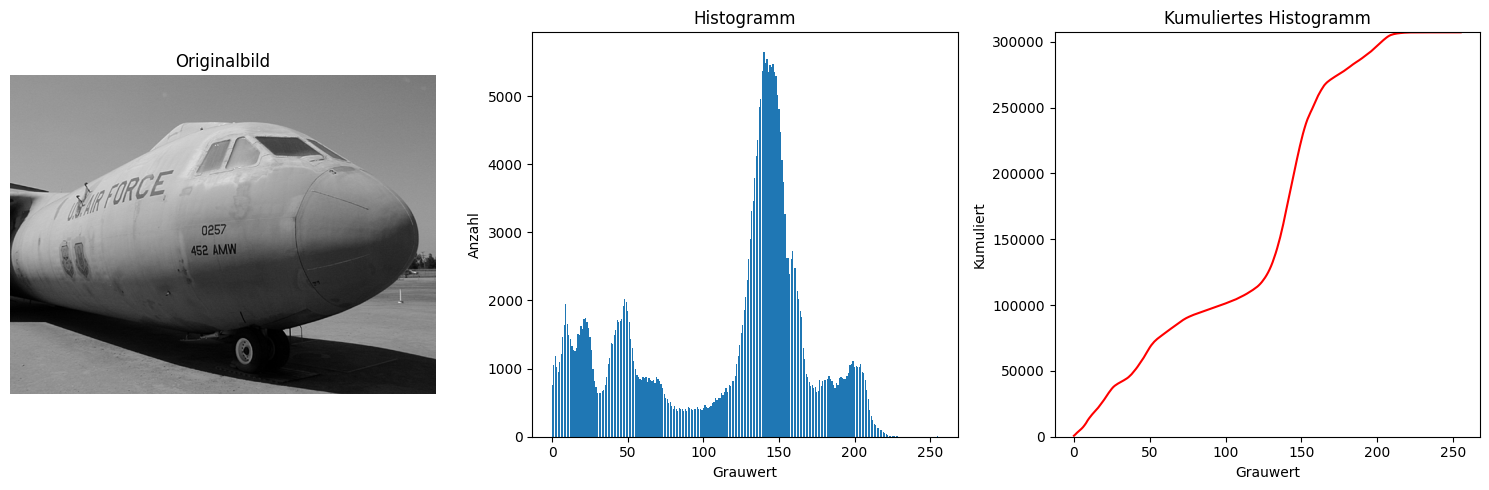

In [4]:
dataType = image.dtype
imageShape = image.shape
print(f'Datentyp des Bildes: {dataType}')
print(f'fortmat des Bildes: {imageShape}')


displayImageAndAllHist(image, title = 'Originalbild')

## Invertieren des Bildes

#### Aufgabe:

Invertieren Sie das Bild und zeigen Sie das invertierte Bild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().

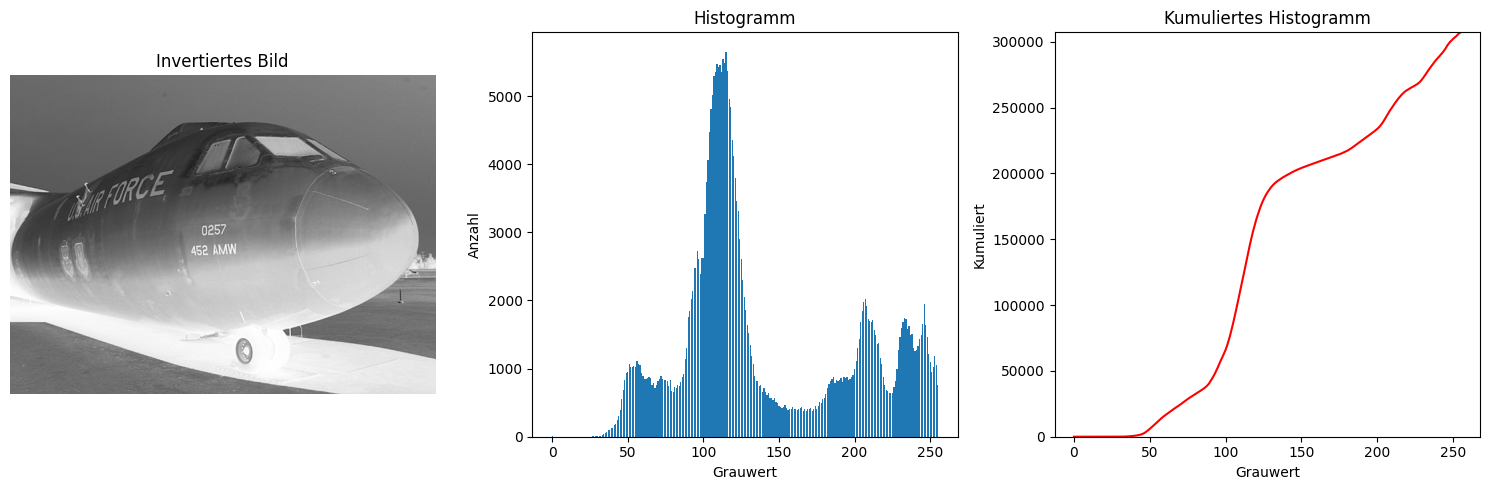

In [5]:
##########
### ENTER YOUR CODE HERE
##########
#Invertierung des Bildes:

#inverted_image = ????????



image_inverted = 255-image

displayImageAndAllHist(image_inverted, title = 'Invertiertes Bild')

### Schwellwertoperation

#### Aufgabe:
Implemenieren Sie eine Funktion die das Bild durch eine Schwellwertoperation in ein Binärbild umwandelt.  Zeigen Sie das Ergebnisbild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().
Wandeln Sie das Bild durch eine Schwellwertoperation in ein Binärbild um. Zeigen Sie das Ergebnisbild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().
Spielen Sie mit unterschiedlichen Werten von threshold

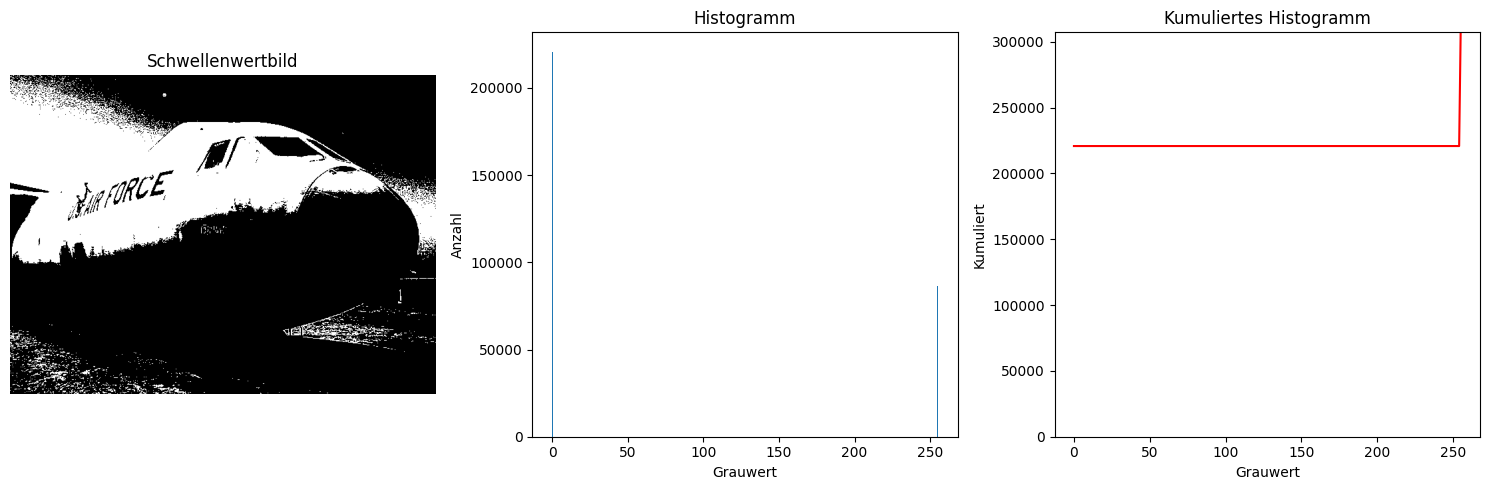

In [6]:
def thresholdImage(image, threshold):
    """Apply a threshold operation to convert the image to a binary image.

    Parameters:
    - image (numpy.ndarray): uint8 image, grayscale
    - threshold (int): Threshold value.

    Returns:
    - numpy.ndarray: Binary image after thresholding.
    """

    ##########
    ### ENTER YOUR CODE HERE
    ##########

    # image_threshold = ??????

    image_threshold = np.where(image >= threshold, 255, 0).astype(np.uint8)
    return image_threshold


threshold = 150
image_threshold = thresholdImage(image, threshold)

# Anzeige von Bild und Histogramm
displayImageAndAllHist(image_threshold, title = 'Schwellenwertbild')

### Helligkeit und Kontrast

#### Aufgabe:

Implementieren Sie eine Funktion adjustBrightnessContrast(image, brightness, contrast), die die Helligkeit und den Kontrast eines Grauwertbildes anpasst.

Als Eingangeparameter erhält die Funktion:
- image: Das Eingangsbild 
- brightness: als int, Wertbereich -255 bis +255
- contrast: als float

Die Funktion soll das modifizierte Bild zurückgeben.

***Hinweis***
Die Anpassung von Helligkeit und Kontrast verlässt normalerweise den Wertebereich `uint8` Wandeln Sie daher zuerst das Bild in float Datantyp (Fließkommazahl) um und führen Sie die Berechnung hier durch.

Passen Sie dann das Datenformat vor der Rückgabe des Bildes wieder an. 

Nutzen Sie hierzu die Befehle:\
* np.clip(....) zur Beschränkung des Wertebereiches [https://numpy.org/devdocs/reference/generated/numpy.clip.html](https://numpy.org/devdocs/reference/generated/numpy.clip.html)
* np.astype() zur Änderung des Variablentyps

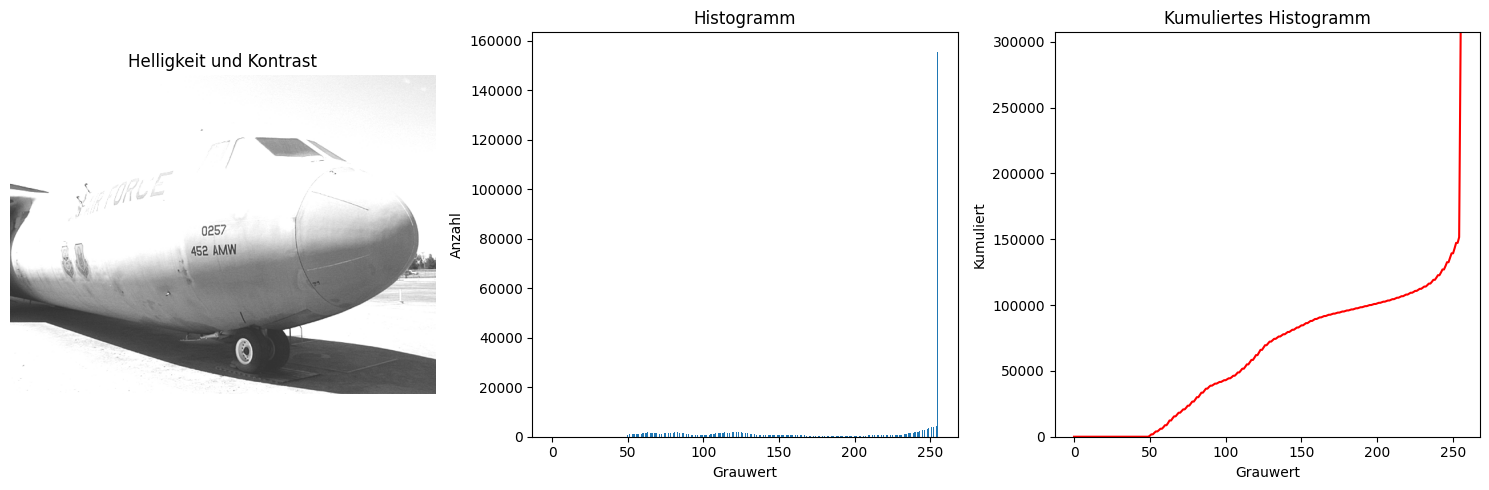

In [7]:
def adjustBrightnessContrast(image, brightness, contrast):
    '''
    Passt die Helligkeit und den Kontrast eines Grauwertbildes an.
    
    Parameter:
    - image: Eingangsbild (2D numpy array) uint8, grayscale
    - brightness: Helligkeitswert (int, Bereich -255 bis +255)
    - contrast: Kontrastwert (float)
    
    Rückgabe:
    - Angepasstes Bild (2D numpy array), uint8, grayscale
    '''

    ##########
    ### ENTER YOUR CODE HERE
    ##########
    # Change data Type to float64 for calculation
    image_float = image.astype(np.float64)


    # adjust brtightness and contrast
    adjusted = image_float* contrast + brightness

    #Scale values to [0,255] and change data type back to uint8
    adjusted = np.clip(adjusted, 0, 255).astype(np.uint8)
    
    return adjusted

# Aufruf der Funktion und test
brightness = 50
contrast = 1.5

image_bright_contrast = adjustBrightnessContrast(image, brightness, contrast)
displayImageAndAllHist(image_bright_contrast, title = 'Helligkeit und Kontrast')

Aufruf der Funktion und Anzeige des Bildes:

### Gamma - Korrektur

#### Aufgabe: 
Implementieren Sie eine Funktion adjustGamma(image, gamma), die eine Gamma-Korrektur auf ein Grauwertbild anwendet.

Gehen Sie dabei folgendermaßen vor:
- wandeln sie das Bild zuerst in einen float datentyp um. Skalieren sie das Bild dabei so, dass die Werte im Beich zwischen 0 und 1 liegen.
 
- wenden Sie die Gamma Korrektur an
- skalieren Sie das Bild wieder auf den Wertebereich 0 bis 255.

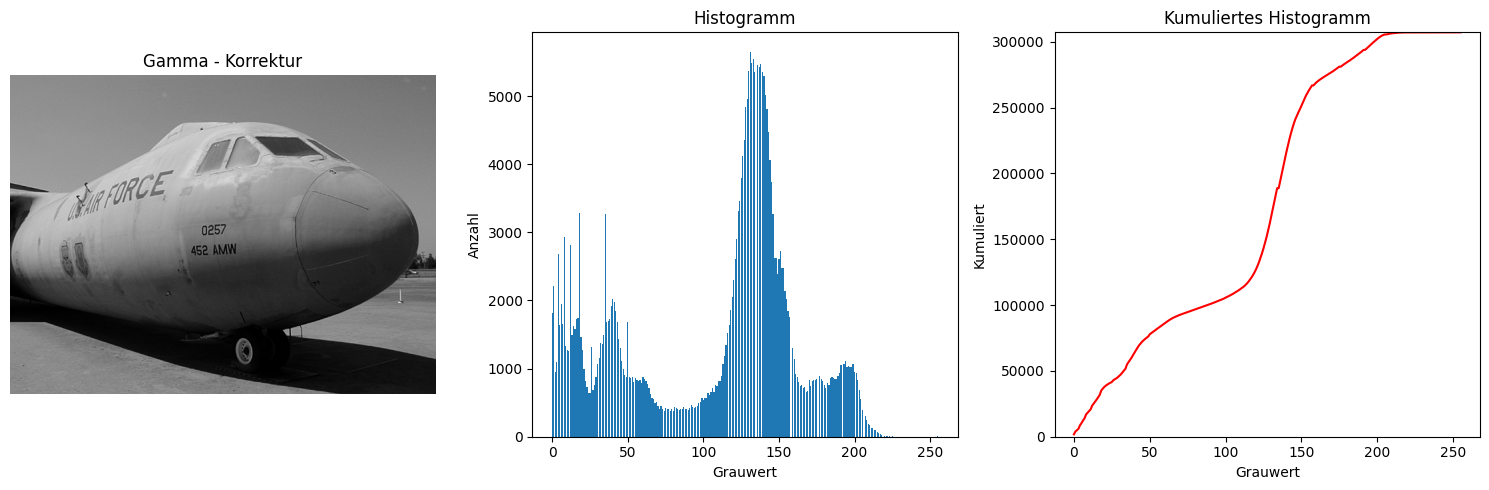

In [8]:
def adjustGamma(image, gamma):
    """Apply gamma correction to a grayscale image.

    Parameters:
    - image (numpy.ndarray): Input uint8 grayscale image.
    - gamma (float): Gamma value (>0). Values <1 brighten, >1 darken.
    Returns:
    - numpy.ndarray: Gamma-corrected image (uint8).
    """
    ##########
    ### ENTER YOUR CODE HERE
    ##########
    image_normalized = image.astype(np.float32) / 255.0
    # apply gamma
    image_corrected = image_normalized**gamma

    # clipping
    image_corrected = image_corrected * 255.0
    image_corrected = np.clip(image_corrected, 0, 255).astype(np.uint8)
    
    return image_corrected

# Aufruf der Funktion und Test
gamma = 1.1

image_gamma = adjustGamma(image, gamma)
displayImageAndAllHist(image_gamma, title = 'Gamma - Korrektur')

### Zusatzaufgabe
#### Automatisierte Berechnung eines optimalen Schwellwerts
*Interessierte können diese Aufgabe als zusätzliche Übung durchführen*

Im ersten Übungsteil wurde die Funktion `thresholdImage(image, threshold)` implementiert. Diese Funktion wendet eine Schwellwertoperation auf ein Grauwertbild an, wobei der Schwellwert als Parameter übergeben wird. In dieser Zusatzaufgabe soll eine Funktion `autoThreshold(image)` implementiert werden, die automatisch einen optimalen Schwellwert für das gegebene Bild berechnet und das binäre Bild zurückgibt.
Solch eine automatisierte Schwellwertberechnung wird häufig bei der Bildsegmentierung eingesetzt, um Objekte von ihrem Hintergrund zu trennen. Im Normalfall sind Hintergrund- und Vordergrundpixel nicht gleich häufig, sodass eine rein statistische Methode zur Schwellwertbestimmung nicht zielführend ist. Daher sind automatisierte Methoden zur Schwellwerbestimmung entwas aufwändiger.
im Folgenden soll die Isodata Methode implementiert werden.
Der Algorithmus is en Detail in Burge Kapitel 11.1.2 beschrieben. Im Wesentlichen wird dabei iterativ ein Schwellwert berechnet, der die Pixel in zwei Gruppen teilt. Für jede Gruppe wird der Mittelwert berechnet und der neue Schwellwert als Durchschnitt dieser beiden Mittelwerte festgelegt. Dieser Prozess wird so lange wiederholt, bis sich der Schwellwert nicht mehr ändert.


##### Vorgehen

implementieren Sie die Funktion `autoThreshold_Isodata(image)`, die den automatischen Schwellwert berechnet. Um das Bild zu binärtisieren rufen Sie dann die Funktion `thresholdImage(image, threshold)` mit dem berechneten Schwellwert auf.

In [14]:
def autoThreshold_Isodata(image):
    """Calculate an automatic threshold using the Isodata method.

    Parameters:
    - image (numpy.ndarray): Input uint8 grayscale image.

    Returns:
    - int: Calculated threshold value.
    """
    ##########
    ### ENTER YOUR CODE HERE
    ##########
    
    # Initial threshold can be the mean of the pixel values
    threshold = np.mean(image)
    
    while True:
        # Split the image into two groups based on the current threshold
        group1 = image[image >= threshold]
        group2 = image[image < threshold]
        
        # Calculate the mean of each group
        mean1 = np.mean(group1) if len(group1) > 0 else 0
        mean2 = np.mean(group2) if len(group2) > 0 else 0
        
        # Calculate the new threshold as the average of the two means
        new_threshold = (mean1 + mean2) / 2
        
        # Check for convergence (if the new threshold is the same as the old one)
        if new_threshold == threshold:
            break
        
        threshold = new_threshold
    
    return int(threshold)



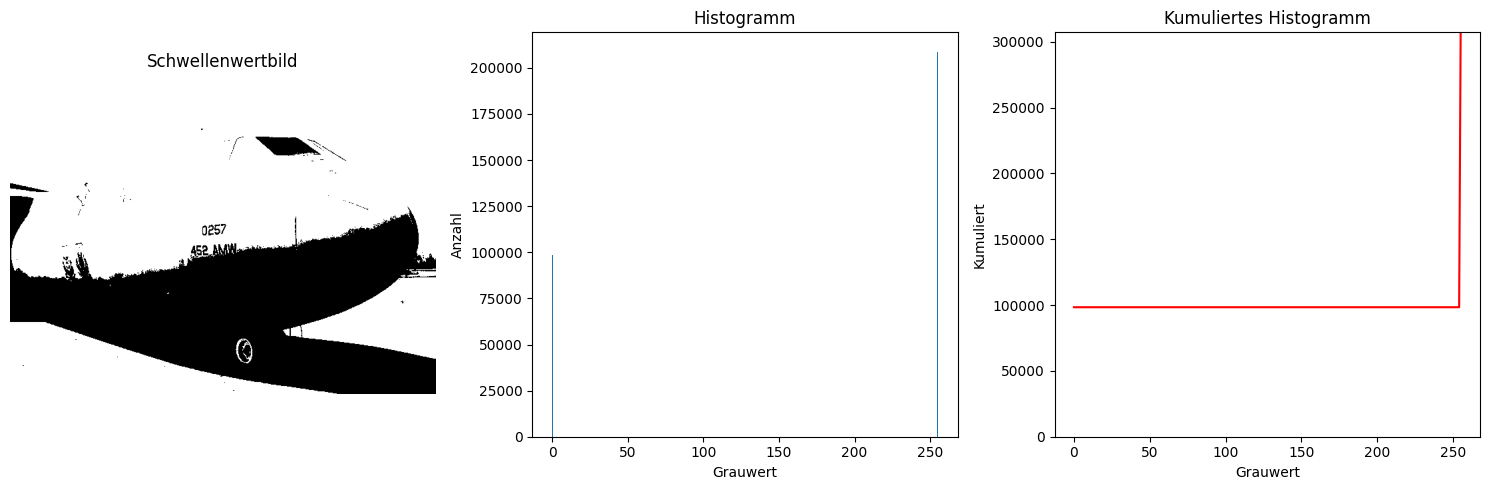

In [15]:
auto_threshold = autoThreshold_Isodata(image)
image_threshold = thresholdImage(image, auto_threshold)
# Anzeige von Bild und Histogramm
displayImageAndAllHist(image_threshold, title = 'Schwellenwertbild')